# **<p align="center"> Title </p>**

## <ins> Description </ins>
### The goal of this notebook is to compare the locally calculated Conformational Entropy (Crystal Order Parameter) values, and compare them to the paper ones.

<details open>
<summary> <font size="6"> <ins>Key Points 2 </ins> </font> </summary>

- bulletpoint1

-  bulletpoint1

- [link]()

- image1: <img src="" width = 50%>

</details>

</br>

<details open>
<summary> <font size = "6"> <ins> Key Points 2 </ins> </font> </summary>

- `bulletpoint1`


- `bulletpoint2`



</details>

</br>


---

In [99]:
# Set up variables and imports
from pathlib import Path
root_dir = Path("../../../")
import re
import numpy as np
import pandas as pd
import sys
sys.path.insert(0, root_dir.__str__())
from shutil import copy2, move
import pickle as pkl

import gemmi

from xaidar.data.molecModels import loadPDB, get_pdb_stats, sele_pdb, sele_AA

qfit_dir = root_dir.joinpath("qfit-3.0")
data_dir = root_dir.joinpath("data/entropy/wankowicz")
qfit_pdb_dir = data_dir.joinpath("18209769")
orderParam_dir = data_dir.joinpath("orderParam_analysis")

## Bullet point 1

- ###  Paper Experimental Data (media-1.csv)

#### Extract Data from csv

In [142]:
paper_exp_data = data_dir.joinpath("media-1.csv")
paper_exp_df = pd.read_csv(paper_exp_data)
display( paper_exp_df.sort_values("Bound PDB")[ paper_exp_df["Protein"] ==  "thermolysin" ].head(10) )
paper_exp_df = paper_exp_df[ [ "Protein", "Bound PDB", "Apo PDB", "-TdS (kcal/mol)", "Temperature" ] ]
paper_exp_df.head(10)
# Set all the pdb labels to lowercase for easier merging later
paper_exp_df["Bound PDB"] = paper_exp_df["Bound PDB"].str.lower()
paper_exp_df["Apo PDB"] = paper_exp_df["Apo PDB"].str.lower()

C:\Users\AlexBelo\AppData\Local\Temp\ipykernel_21300\1242205283.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  display( paper_exp_df.sort_values("Bound PDB")[ paper_exp_df["Protein"] ==  "thermolysin" ].head(10) )


,Protein,Bound PDB,Apo PDB,dG (kcal/mol),dH (kcal/mol),-TdS (kcal/mol),Temperature,Cell Content,Ligand Content,Cell Concentration,Ligand Concentration,Run Num,Citation (DOI),Paper Ligand Tracker,Notes
1,thermolysin,3T73,1KEI,-7.538580,-3.603000,-3.935580,25,200uL protein,ligand,30 uM protein,0.4 mM,a,10.1002/cmdc.201200206,TLN-1,NaN
2,thermolysin,3T73,1KEI,-7.675580,-3.740000,-3.935580,25,200uL protein,ligand,30 uM protein,0.4 mM,b,10.1002/cmdc.201200206,TLN-1,NaN
3,thermolysin,3T73,1KEI,-7.613950,-3.738000,-3.875950,25,200uL protein,ligand,30 uM protein,0.4 mM,c,10.1002/cmdc.201200206,TLN-1,NaN
0,thermolysin,3T73,1KEI,-7.600382,-3.704589,-3.895793,25,200uL protein,ligand,45 uM protein,1-1.5 mM,summary data,10.1002/cmdc.201200206,TLN-1,info in different paper than ligands 2-9 (corr...
5,thermolysin,3T8F,1KEI,-8.054493,-4.923518,-3.130975,25,200uL protein,ligand,30 uM protein,0.4 mM,"2 - Krimmer et al., 2014 summary",10.1002/cmdc.201400013,TLN-2,NaN
4,thermolysin,3T8F,1KEI,-8.126200,-3.107070,-5.019120,25,200uL protein,ligand,45 uM protein,1-1.5 mM,"1 - Biela et al., 2012 summary",10.1002/cmdc.201200206,TLN-2,measurements in multiple papers
7,thermolysin,3T8F,1KEI,-8.075575,-4.945000,-3.130575,25,200uL protein,ligand,30 uM protein,0.4 mM,b,10.1002/cmdc.201400013,TLN-2,NaN
8,thermolysin,3T8F,1KEI,-8.018130,-4.977000,-3.041130,25,200uL protein,ligand,30uM protein,0.4 mM,c,10.1002/cmdc.201400013,TLN-2,NaN
6,thermolysin,3T8F,1KEI,-8.056205,-4.866000,-3.190205,25,200uL protein,ligand,30 uM protein,0.4 mM,a,10.1002/cmdc.201400013,TLN-2,NaN
9,thermolysin,4MTW,1KEI,-9.058317,-5.114723,-3.943595,25,200uL protein,ligand,30uM protein,0.4mM,summary data,10.1002/cmdc.201400013,TLN-4,NaN


#### Get Mean ITC values per protein

In [141]:
# mean of -TdS per label (edit label_cols as needed)
label_cols = ["Protein", "Bound PDB", "Apo PDB"]

mean_per_label = (
    paper_exp_df
    .groupby(label_cols, as_index=False)["-TdS (kcal/mol)"]
    .mean()
    .rename(columns={"-TdS (kcal/mol)": "mean_-TdS"})
)

display( mean_per_label.sort_values("Apo PDB").sort_values("Bound PDB")[ mean_per_label["Protein"] ==  "thermolysin" ].head(12))

C:\Users\AlexBelo\AppData\Local\Temp\ipykernel_21300\54822278.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  display( mean_per_label.sort_values("Apo PDB").sort_values("Bound PDB")[ mean_per_label["Protein"] ==  "thermolysin" ].head(12))


,Protein,Bound PDB,Apo PDB,mean_-TdS
61,thermolysin,3t73,1kei,-3.910726
62,thermolysin,3t8f,1kei,-3.502401
63,thermolysin,4mtw,1kei,-3.945038
64,thermolysin,4mwp,1kei,-5.475324
65,thermolysin,4mxj,1kei,-2.584036
66,thermolysin,4mzn,3do2,-3.958466
67,thermolysin,4n4e,1kei,-5.208346
68,thermolysin,4n5p,1kei,-4.674391
69,thermolysin,4n66,1kei,-5.475324
70,thermolysin,5js3,3do2,-4.116874


#### Get Paper Computed Values

In [101]:
paper_comp_data = data_dir.joinpath("media-2.csv")
paper_comp_df = pd.read_csv(paper_comp_data)
paper_comp_df["PDB"] = paper_comp_df["PDB"].str.lower()
paper_comp_df.sort_values("PDB")[ paper_comp_df["Protein"] ==  "Thermolysin" ]
paper_comp_df = paper_comp_df[ [ "PDB", "Protein_Entropy" ] ]

C:\Users\AlexBelo\AppData\Local\Temp\ipykernel_21300\3482352957.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  paper_comp_df.sort_values("PDB")[ paper_comp_df["Protein"] ==  "Thermolysin" ]


#### Link the paper_comp_df to the paper_exp_df by PDB code to get the experimental -TdS values for the same PDBs

In [102]:
# Link the paper_comp_df to the paper_exp_df by PDB code to get the experimental -TdS values for the same PDBs
merged_df = pd.merge(paper_comp_df, mean_per_label, left_on="PDB", right_on="Bound PDB", how="inner")
# merged_df = merged_df[ [ "PDB", "Protein_Entropy", "-TdS (kcal/mol)" ] ]
merged_df.sort_values("Apo PDB").sort_values("Bound PDB")[ merged_df["Protein"] ==  "thermolysin" ].head(12)[ ["PDB",	"Protein_Entropy", "mean_-TdS", ] + label_cols ]

C:\Users\AlexBelo\AppData\Local\Temp\ipykernel_21300\2061115175.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  merged_df.sort_values("Apo PDB").sort_values("Bound PDB")[ merged_df["Protein"] ==  "thermolysin" ].head(12)[ ["PDB",	"Protein_Entropy", "mean_-TdS", ] + label_cols ]


,PDB,Protein_Entropy,mean_-TdS,Protein,Bound PDB,Apo PDB
52,3t73,-3.6050,-3.910726,thermolysin,3t73,1kei
62,3t8f,2.1825,-3.502401,thermolysin,3t8f,1kei
61,4mtw,0.2325,-3.945038,thermolysin,4mtw,1kei
56,4mwp,-0.9750,-5.475324,thermolysin,4mwp,1kei
58,4mxj,-0.9425,-2.584036,thermolysin,4mxj,1kei
53,4n4e,-2.8575,-5.208346,thermolysin,4n4e,1kei
57,4n5p,-0.9475,-4.674391,thermolysin,4n5p,1kei
55,4n66,-2.0125,-5.475324,thermolysin,4n66,1kei
60,5jt9,-0.4525,-3.955545,thermolysin,5jt9,3do2
54,5jvi,-2.1650,-4.851816,thermolysin,5jvi,3do2


### Get my computed order parameters and conformational entropy for each structure

In [103]:
my_comp_data = orderParam_dir.joinpath("conf_ent_dict.pkl")
with open(my_comp_data, "rb") as f:
    conf_ent_dict = pkl.load(f)
my_comp_df = pd.DataFrame( conf_ent_dict.items(), columns=["My_PDB", "My_Conf_Entropy"] )
display( my_comp_df.sort_values("My_PDB") )

,My_PDB,My_Conf_Entropy
0,1cai,47.45265
1,1f41,19.98390
2,1kei,59.39445
3,1qy0,29.32760
4,1qy1,29.39040
...,...,...
69,6i0w,0.00000
70,6i1u,0.00000
71,6i2f,0.00000
72,6i3e,0.00000


#### Compute My Delta Entropy and merge with the merged_df

In [143]:

new_merged_df = pd.merge(merged_df, my_comp_df, left_on="Apo PDB", right_on="My_PDB", how="inner").drop(columns=["My_PDB"]).rename(columns={"My_Conf_Entropy": "My_Conf_Entropy_Apo"})
new_merged_df = pd.merge(new_merged_df, my_comp_df, left_on="Bound PDB", right_on="My_PDB", how="inner").drop(columns=["My_PDB"]).rename(columns={"My_Conf_Entropy": "My_Conf_Entropy_Holo"})
new_merged_df["My_Delta_Ent"] = new_merged_df["My_Conf_Entropy_Holo"] - new_merged_df["My_Conf_Entropy_Apo"]
new_merged_df = new_merged_df[ [ "PDB", "mean_-TdS", "Protein_Entropy",  "My_Delta_Ent" , "My_Conf_Entropy_Apo", "My_Conf_Entropy_Holo"] + label_cols ]
final_df = new_merged_df[ (new_merged_df["My_Conf_Entropy_Apo"] != 0) & (new_merged_df["My_Conf_Entropy_Holo"] != 0)  ]
missing_pdb_df = new_merged_df[ (new_merged_df["My_Conf_Entropy_Apo"] == 0) | (new_merged_df["My_Conf_Entropy_Holo"] == 0)  ]
print("Table with My_Delta_Ent values:")
display( final_df.iloc[ :5, :6] )
print("Table with missing My_Delta_Ent values:")
display( missing_pdb_df.iloc[:, 0:6].sort_values( "My_Delta_Ent", key=lambda s: s.abs()) )

Table with My_Delta_Ent values:


,PDB,mean_-TdS,Protein_Entropy,My_Delta_Ent,My_Conf_Entropy_Apo,My_Conf_Entropy_Holo
0,3u5l,-2.00,-0.164996,0.030950,23.10210,23.133050
1,4mr3,2.74,0.885921,0.697700,23.10210,23.799800
2,4mr4,0.04,1.163739,0.783425,23.10210,23.885525
4,3u5j,-0.44,2.591442,2.294725,23.10210,25.396825
5,6ajx,1.30,2.890000,2.799700,22.98905,25.788750


Table with missing My_Delta_Ent values:


,PDB,mean_-TdS,Protein_Entropy,My_Delta_Ent,My_Conf_Entropy_Apo,My_Conf_Entropy_Holo
43,5jvi,-4.851816,-2.165000,0.00000,0.00000,0.0000
3,3mxf,-3.650000,2.089548,-23.10210,23.10210,0.0000
9,2xg3,5.258126,1.137500,-23.83605,23.83605,0.0000
13,4yxi,0.782425,0.880000,-43.96965,43.96965,0.0000
17,6rl9,3.226577,1.857500,-43.96965,43.96965,0.0000
11,6i3e,1.906669,0.735000,-44.35820,44.35820,0.0000
12,6hr3,-0.445148,0.860000,-44.35820,44.35820,0.0000
14,6i0w,1.956860,1.172500,-44.35820,44.35820,0.0000
15,6i1u,1.674833,1.397500,-44.35820,44.35820,0.0000
16,6hqx,0.289794,1.772500,-44.35820,44.35820,0.0000


#### Visualize and compare my computed values with values computed by Paper

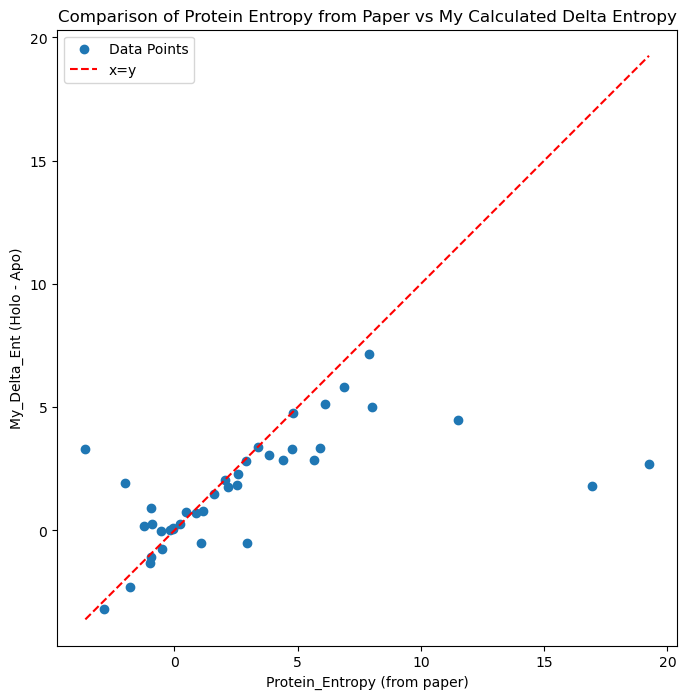

In [123]:
# final_df Protein_Entropy VS My_Delta_Ent
# plot 1 to 1 axis scatter plot of Protein_Entropy (from paper) vs My_Delta_Ent (Holo - Apo)
import matplotlib.pyplot as plt 
fig = plt.figure(figsize=(8,8))
plt.scatter(final_df["Protein_Entropy"], final_df["My_Delta_Ent"])
x = np.linspace(final_df["Protein_Entropy"].min(), final_df["Protein_Entropy"].max(), 100)
y = x
plt.plot(x, y, color="red", linestyle="--")
plt.xlabel("Protein_Entropy (from paper)")
plt.ylabel("My_Delta_Ent (Holo - Apo)")
plt.title("Comparison of Protein Entropy from Paper vs My Calculated Delta Entropy")
plt.legend(["Data Points", "x=y"])
# square plot with equal aspect ratio
plt.axis('equal')
plt.show()
